# Sales Prediction Visualization

Este notebook demonstra a visualização dos modelos de regressão linear para previsão de vendas por produto.


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sales_prediction import SalesPredictionDB
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (18, 6)

## 1. Load and Prepare Data


In [2]:
# Initialize predictor
predictor = SalesPredictionDB()

# Load data from database
predictor.load_data()

# Prepare data for training
predictor.demand_forecast = predictor.prepare_data()

# Get unique product IDs
product_ids = predictor.demand_forecast['product_id'].unique()
print(f"\nProducts available for analysis: {product_ids}")

Data loaded successfully for user_id=1
Products: 3
Sales: 5
Sale Items: 6
~ prepare_data - product_sales: 
   id sale_id product_id  quantity  unit_price  subtotal           created_at
0  1       1          1         2        15.0      30.0  2025-10-07 23:05:30
1  2       1          2         1       199.0     199.0  2025-10-07 23:06:10
2  3       2          1         4       199.0     800.0  2025-10-07 15:00:00
3  4       3          2         2       199.0     398.0  2025-10-07 23:05:30
4  5       4          2         5       199.0     995.0  2025-10-07 23:05:30
5  6       5          2         1       199.0     199.0  2025-10-07 23:05:30
~ prepare_data - sales: 
   id sale_number  user_id  total_amount     status            sale_date  \
0  1           1        1           1.0  COMPLETED  2025-10-07 00:00:00   
1  2           2        1           1.0  COMPLETED  2025-10-10 00:00:00   
2  3           3        1           1.0  COMPLETED  2025-10-12 00:00:00   
3  4           4        1  

## 2. Train Models and Store Results


In [3]:
# Dictionary to store all trained models and results
results = {}

for product_id in product_ids:
    print(f"\n{'='*80}")
    print(f"Training model for Product ID: {product_id}")
    print(f"{'='*80}")
    
    # Train model
    trained_model = predictor.train_model(product_id)
    
    if trained_model is None:
        continue
    
    # Evaluate model
    metrics = predictor.evaluate_model(trained_model)
    
    # Predict future (next 30 days)
    future_predictions = predictor.predict_future(trained_model, days_ahead=30)
    
    # Store results
    results[product_id] = {
        'trained_model': trained_model,
        'metrics': metrics,
        'future_predictions': future_predictions
    }

print(f"\n\nTotal models trained: {len(results)}")


Training model for Product ID: 1

Training model for product_id=1
Total records: 2
Date range: 2025-10-07 00:00:00 to 2025-10-10 00:00:00

Model trained successfully!
Coefficients: [0.33333333 0.33333333 0.        ]
Intercept: 1.6667

Model Evaluation - Product ID: 1
R² (R-squared):               100.00% - Model explains 100.00% of variance
MAE (Mean Absolute Error):    0.0000 units
MAPE (Mean Absolute % Error): 0.00%

Model Quality: Excellent

Future Predictions - Product ID: 1
Predicting from 2025-10-11 to 2025-11-09

First 10 predictions:
   sale_date  predicted_quantity
0 2025-10-11            4.666667
1 2025-10-12            5.333333
2 2025-10-13            3.666667
3 2025-10-14            4.333333
4 2025-10-15            5.000000
5 2025-10-16            5.666667
6 2025-10-17            6.333333
7 2025-10-18            7.000000
8 2025-10-19            7.666667
9 2025-10-20            6.000000

Average predicted demand: 8.89 units/day
Total predicted demand: 266.67 units

Training

## 3. Visualization - Individual Product Analysis

Similar ao gráfico do notebook linear_regression.ipynb, mostrando:

- Dados históricos (pontos azuis)
- Linha de regressão (linha vermelha)
- Previsões futuras (pontos verdes)


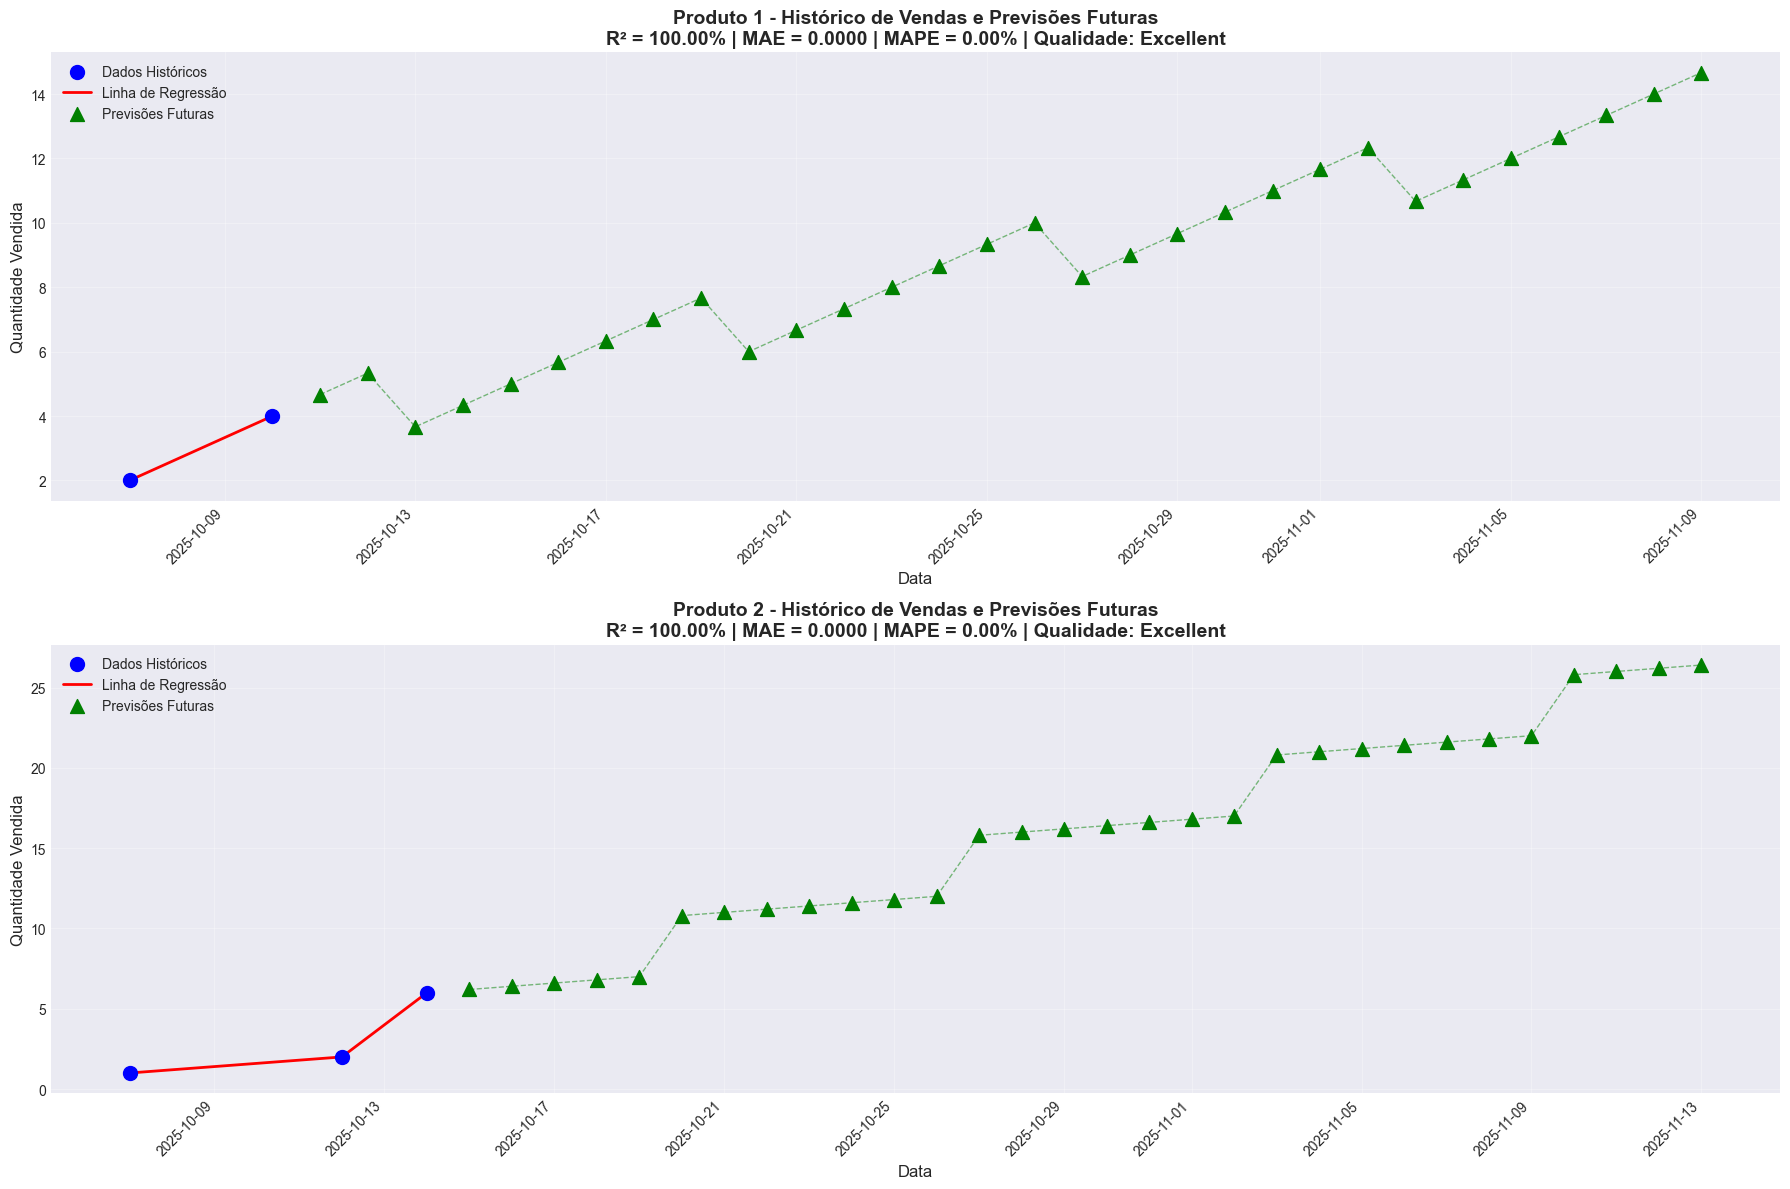

In [4]:
# Create subplot for each product
n_products = len(results)
fig, axes = plt.subplots(n_products, 1, figsize=(18, 6 * n_products))

# Handle single product case (axes won't be array)
if n_products == 1:
    axes = [axes]

for idx, (product_id, data) in enumerate(results.items()):
    ax = axes[idx]
    
    trained_model = data['trained_model']
    metrics = data['metrics']
    future_predictions = data['future_predictions']
    
    product_data = trained_model['product_data']
    
    # Historical data (scatter plot)
    ax.scatter(
        product_data['sale_date'],
        product_data['quantity'],
        color='blue',
        s=100,
        label='Dados Históricos',
        zorder=3
    )
    
    # Regression line (predictions for historical data)
    ax.plot(
        product_data['sale_date'],
        trained_model['y_pred'],
        color='red',
        linewidth=2,
        label='Linha de Regressão',
        zorder=2
    )
    
    # Future predictions (scatter plot)
    ax.scatter(
        future_predictions['sale_date'],
        future_predictions['predicted_quantity'],
        color='green',
        s=100,
        label='Previsões Futuras',
        marker='^',
        zorder=3
    )
    
    # Connecting line for future predictions
    ax.plot(
        future_predictions['sale_date'],
        future_predictions['predicted_quantity'],
        color='green',
        linewidth=1,
        linestyle='--',
        alpha=0.5,
        zorder=1
    )
    
    # Labels and title
    ax.set_xlabel('Data', fontsize=12)
    ax.set_ylabel('Quantidade Vendida', fontsize=12)
    ax.set_title(
        f'Produto {product_id} - Histórico de Vendas e Previsões Futuras\n'
        f'R² = {metrics["r2"]*100:.2f}% | MAE = {metrics["mae"]:.4f} | MAPE = {metrics["mape"]:.2f}% | Qualidade: {metrics["quality"]}',
        fontsize=14,
        fontweight='bold'
    )
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Rotate x-axis labels for better readability
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 4. Summary Comparison - All Products


In [5]:
# Create summary DataFrame
summary_data = []

for product_id, data in results.items():
    metrics = data['metrics']
    future_predictions = data['future_predictions']
    
    summary_data.append({
        'Product ID': product_id,
        'R² (%)': f"{metrics['r2']*100:.2f}%" if not np.isnan(metrics['r2']) else 'N/A',
        'MAE': f"{metrics['mae']:.4f}",
        'MAPE (%)': f"{metrics['mape']:.2f}%",
        'Quality': metrics['quality'],
        'Avg Daily Demand (30d)': f"{future_predictions['predicted_quantity'].mean():.2f}",
        'Total Demand (30d)': f"{future_predictions['predicted_quantity'].sum():.2f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("SUMMARY - ALL PRODUCTS")
print("="*100)
print(summary_df.to_string(index=False))
print("="*100)


SUMMARY - ALL PRODUCTS
Product ID  R² (%)    MAE MAPE (%)   Quality Avg Daily Demand (30d) Total Demand (30d)
         1 100.00% 0.0000    0.00% Excellent                   8.89             266.67
         2 100.00% 0.0000    0.00% Excellent                  16.06             481.80


## 5. Model Performance Comparison


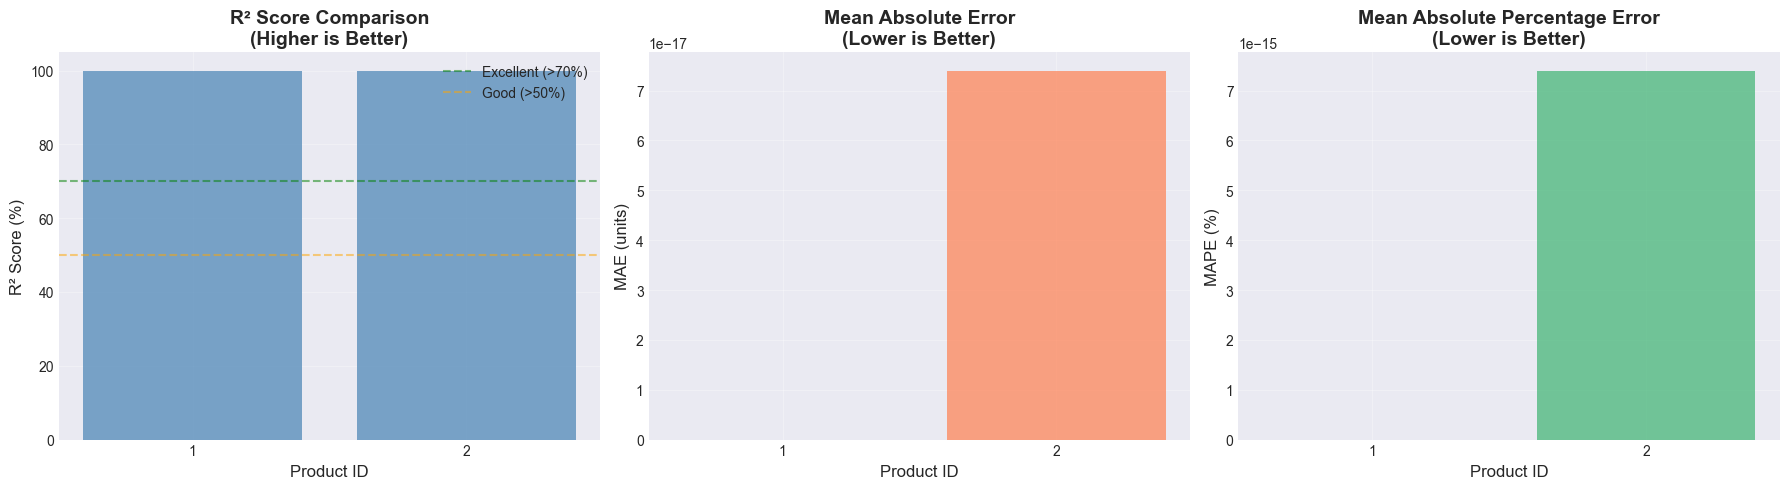

In [6]:
# Extract metrics for comparison
product_names = [str(pid) for pid in results.keys()]
r2_scores = [results[pid]['metrics']['r2']*100 if not np.isnan(results[pid]['metrics']['r2']) else 0 
             for pid in results.keys()]
mae_scores = [results[pid]['metrics']['mae'] for pid in results.keys()]
mape_scores = [results[pid]['metrics']['mape'] for pid in results.keys()]

# Create comparison plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R² Comparison
axes[0].bar(product_names, r2_scores, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Product ID', fontsize=12)
axes[0].set_ylabel('R² Score (%)', fontsize=12)
axes[0].set_title('R² Score Comparison\n(Higher is Better)', fontsize=14, fontweight='bold')
axes[0].axhline(y=70, color='green', linestyle='--', label='Excellent (>70%)', alpha=0.5)
axes[0].axhline(y=50, color='orange', linestyle='--', label='Good (>50%)', alpha=0.5)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE Comparison
axes[1].bar(product_names, mae_scores, color='coral', alpha=0.7)
axes[1].set_xlabel('Product ID', fontsize=12)
axes[1].set_ylabel('MAE (units)', fontsize=12)
axes[1].set_title('Mean Absolute Error\n(Lower is Better)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# MAPE Comparison
axes[2].bar(product_names, mape_scores, color='mediumseagreen', alpha=0.7)
axes[2].set_xlabel('Product ID', fontsize=12)
axes[2].set_ylabel('MAPE (%)', fontsize=12)
axes[2].set_title('Mean Absolute Percentage Error\n(Lower is Better)', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Future Demand Forecast - Next 30 Days


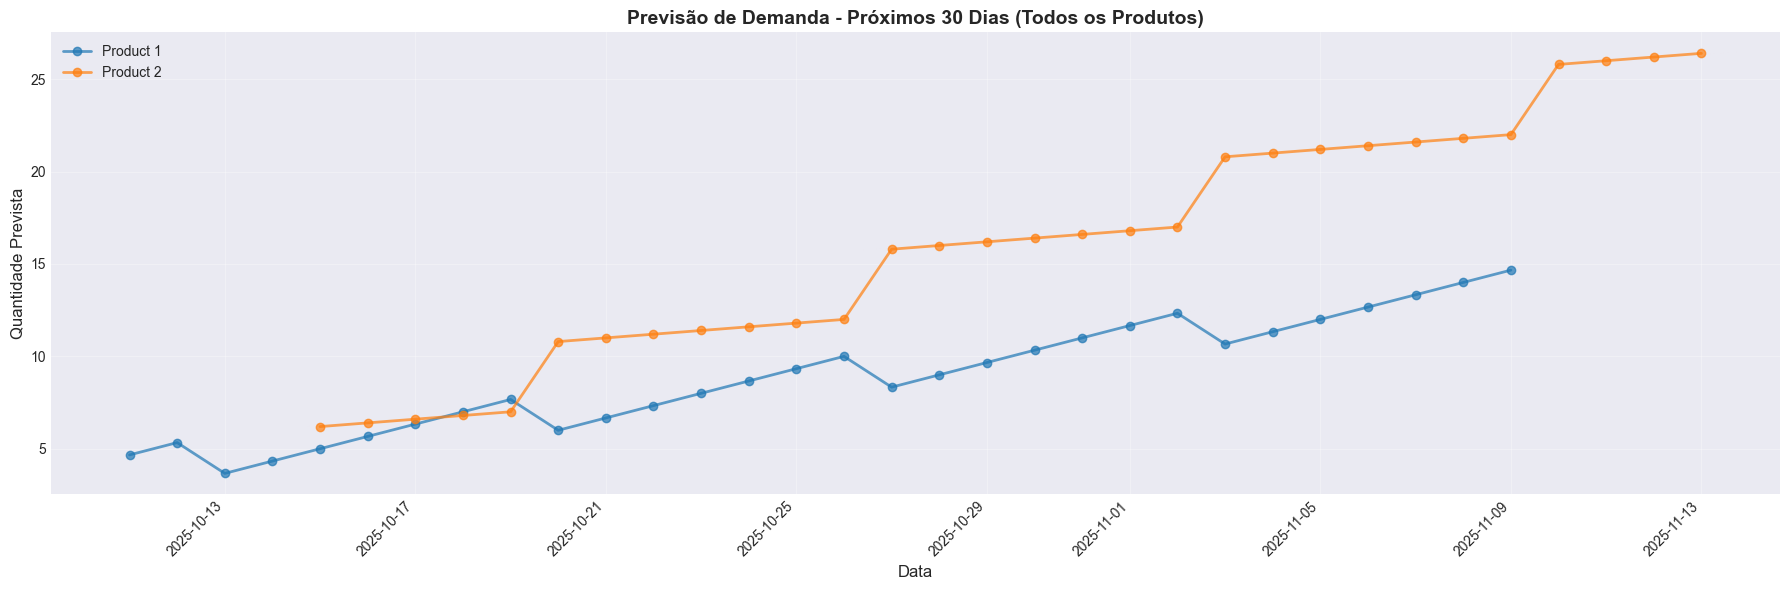

In [7]:
# Plot future predictions for all products
plt.figure(figsize=(18, 6))

for product_id, data in results.items():
    future_predictions = data['future_predictions']
    
    plt.plot(
        future_predictions['sale_date'],
        future_predictions['predicted_quantity'],
        marker='o',
        linewidth=2,
        label=f'Product {product_id}',
        alpha=0.7
    )

plt.xlabel('Data', fontsize=12)
plt.ylabel('Quantidade Prevista', fontsize=12)
plt.title('Previsão de Demanda - Próximos 30 Dias (Todos os Produtos)', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Export Results to CSV


In [8]:
# Combine all future predictions into a single DataFrame
all_predictions = []

for product_id, data in results.items():
    future_predictions = data['future_predictions'].copy()
    future_predictions['product_id'] = product_id
    all_predictions.append(future_predictions[['product_id', 'sale_date', 'predicted_quantity']])

combined_predictions = pd.concat(all_predictions, ignore_index=True)

# Save to CSV
output_file = 'data/future_predictions_30days.csv'
combined_predictions.to_csv(output_file, index=False)
print(f"✓ Future predictions saved to: {output_file}")
print(f"\nPreview:")
print(combined_predictions.head(10))

✓ Future predictions saved to: data/future_predictions_30days.csv

Preview:
  product_id  sale_date  predicted_quantity
0          1 2025-10-11            4.666667
1          1 2025-10-12            5.333333
2          1 2025-10-13            3.666667
3          1 2025-10-14            4.333333
4          1 2025-10-15            5.000000
5          1 2025-10-16            5.666667
6          1 2025-10-17            6.333333
7          1 2025-10-18            7.000000
8          1 2025-10-19            7.666667
9          1 2025-10-20            6.000000
